# Replicating Anderson and Acuna (2004)

This notebook implements the methods in *Search for solar wind-asteroid interactions at Eros* (2004) doi:10.1016/j.asr.2003.03.032.

Follows the 10-minute windows, NSO geometry, equations (1)-(5), 30-degree wake-angle bins, orbit-radius groups, occurrence distributions, difference distributions, and right/left handedness ratios. The extension sections add uncertainty estimates, multiple-testing control, and artifact sensitivity.

In [1]:
from datetime import datetime, timezone
from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal, stats

In [2]:
data_directory = Path("/Users/danywaller/Projects/near/data")
output_directory = Path("/Users/danywaller/Projects/near/output/anderson_acuna_2004")
output_directory.mkdir(parents=True, exist_ok=True)

start = "2000-02-14T15:33:00"
stop = "2001-02-11T00:00:00"

window_seconds = 600
minimum_samples = 10
orbit_radii = np.array([35, 50, 100, 200])
orbit_edges = np.array([30, 42.5, 75, 150, 250])
angle_edges = np.arange(0, 181, 30)

bootstrap_draws = 2000
random_seed = 433

spectral_scan_start = "2001-01-24T00:00:00"
spectral_scan_stop = "2001-01-25T00:00:00"
spectral_window_seconds = 600
spectral_time_bandwidth = 2.5
spectral_taper_count = 4
spectral_minimum_samples = 32
spectral_minimum_coverage = 0.8
spectral_maximum_gap_factor = 5

injection_frequency_hz = 0.02
injection_amplitudes_nt = np.geomspace(0.02, 1.0, 8)
injection_trials = 100

## Load the calibrated NSO archive

The NSO tables supply UTC, DMET, Bx, By, Bz, Btotal, and the Eros-relative spacecraft position. In NSO, +x is sunward, +z is normal to the orbit plane, and +y completes the right-handed system.

In [3]:
def parse_time(value):
    # fix timezone format
    parsed = datetime.fromisoformat(value.replace("Z", "+00:00"))
    if parsed.tzinfo is None:
        parsed = parsed.replace(tzinfo=timezone.utc)
    return parsed.astimezone(timezone.utc)


def load_nso(data_directory, start, stop):
    files = sorted((data_directory / "mag").rglob("nso*.tab"))
    if not files:
        raise FileNotFoundError("no calibrated NSO MAG tables found")
    time_chunks = []
    value_chunks = []
    for path in files:
        raw_times = np.loadtxt(path, delimiter=",", usecols=0, dtype="U32", ndmin=1)
        values = np.loadtxt(
            path, delimiter=",", usecols=(5, 6, 7, 8, 9, 10, 11, 12), ndmin=2
        )
        times = np.array(
            [np.datetime64(value, "ms") for value in raw_times],
            dtype="datetime64[ms]",
        )
        time_chunks.append(times)
        value_chunks.append(values)
    times = np.concatenate(time_chunks)
    values = np.concatenate(value_chunks)
    order = np.argsort(times)
    times = times[order]
    values = values[order]
    first = np.datetime64(parse_time(start).replace(tzinfo=None), "ms")
    last = np.datetime64(parse_time(stop).replace(tzinfo=None), "ms")
    keep = (times >= first) & (times < last)
    keep &= np.isfinite(values).all(axis=1)
    return times[keep], values[keep]


times, values = load_nso(data_directory, start, stop)
dmet = values[:, 0]
field = values[:, 1:5]
position = values[:, 5:8]
print(f"loaded {times.size:,} calibrated NSO samples")
print(f"coverage: {times[0]} to {times[-1]}")

loaded 6,212,647 calibrated NSO samples
coverage: 2000-02-14T15:33:00.820 to 2001-02-10T23:59:52.180


## Equations (1)-(5) in non-overlapping 10-minute windows

For each window, evaluate the mean field, `rx_b`, parallel and perpendicular fluctuations, `r_perp_parallel`, signed transverse area, handedness `p_a_perp`, normalized polarization amplitude `r_a_perp`, wake direction `n_w`, and wake angle `theta_nw`.

In [4]:
def classify_orbit(radius):
    index = np.searchsorted(orbit_edges, radius, side="right") - 1
    if index < 0 or index >= orbit_radii.size:
        return np.nan
    return float(orbit_radii[index])


def analyze_window(window_times, window_field, window_position, window_dmet):
    vectors = window_field[:, :3]
    mean_vector = np.mean(vectors, axis=0)
    mean_b = float(np.linalg.norm(mean_vector))
    mean_position = np.mean(window_position, axis=0)
    radius = float(np.linalg.norm(mean_position))
    if mean_b == 0 or radius == 0:
        return None
    b_hat = mean_vector / mean_b
    b_parallel = vectors @ b_hat
    b_perpendicular = vectors - np.outer(b_parallel, b_hat)
    sigma_parallel = float(np.std(b_parallel, ddof=0))
    sigma_perpendicular = float(
        np.sqrt(np.mean(np.sum(b_perpendicular**2, axis=1)))
    )
    if sigma_parallel == 0 or sigma_perpendicular == 0:
        return None
    step_area_vectors = np.cross(b_perpendicular[:-1], b_perpendicular[1:])
    area_vector = np.sum(step_area_vectors, axis=0)
    area_norm = float(np.linalg.norm(area_vector))
    signed_step_areas = step_area_vectors @ b_hat
    unsigned_area = float(np.sum(np.abs(signed_step_areas)))
    if area_norm == 0 or unsigned_area == 0:
        return None
    signed_area = float(area_vector @ b_hat)
    yz_field = mean_vector.copy()
    yz_field[0] = 0
    yz_norm = float(np.linalg.norm(yz_field))
    if yz_norm == 0 or mean_vector[0] == 0:
        return None
    n_w = np.sign(mean_vector[0]) * yz_field / yz_norm
    radial_hat = mean_position / radius
    theta_nw = float(
        np.degrees(np.arccos(np.clip(radial_hat @ n_w, -1, 1)))
    )
    return {
        "center_unix_s": float(
            np.mean(window_times.astype("datetime64[ms]").astype(np.int64)) / 1000
        ),
        "sample_count": int(window_times.size),
        "mean_abs_dmet_s": float(np.mean(np.abs(window_dmet))),
        "radius_km": radius,
        "orbit_km": classify_orbit(radius),
        "theta_nw_deg": theta_nw,
        "r_dot_b": float(radial_hat @ b_hat),
        "mean_b_nt": mean_b,
        "rx_b": float(mean_vector[0] / mean_b),
        "mean_b_parallel_nt": float(np.mean(b_parallel)),
        "sigma_parallel_nt": sigma_parallel,
        "sigma_perpendicular_nt": sigma_perpendicular,
        "r_perp_parallel": sigma_perpendicular / sigma_parallel,
        "p_a_perp": signed_area / area_norm,
        "p_a_perp_coherence": signed_area / unsigned_area,
        "r_a_perp": signed_area / sigma_perpendicular**2,
        "maximum_btotal_nt": float(np.max(window_field[:, 3])),
    }


def analyze_windows(times, field, position, dmet):
    seconds = times.astype("datetime64[ms]").astype(np.int64) / 1000
    window_id = np.floor(seconds / window_seconds).astype(np.int64)
    _, first_indices, counts = np.unique(
        window_id, return_index=True, return_counts=True
    )
    records = []
    for first, count in zip(first_indices, counts):
        if count < minimum_samples:
            continue
        selection = slice(first, first + count)
        record = analyze_window(
            times[selection],
            field[selection],
            position[selection],
            dmet[selection],
        )
        if record is not None and np.isfinite(record["orbit_km"]):
            records.append(record)
    return {key: np.array([record[key] for record in records]) for key in records[0]}


metrics = analyze_windows(times, field, position, dmet)
print(f"retained {metrics['radius_km'].size:,} ten-minute orbit windows")
for radius in orbit_radii:
    count = np.count_nonzero(metrics["orbit_km"] == radius)
    print(f"{radius:3.0f} km: {count:6,d} windows ({count / 144:.1f} days)")

retained 47,582 ten-minute orbit windows
 35 km: 10,287 windows (71.4 days)
 50 km: 16,967 windows (117.8 days)
100 km: 10,065 windows (69.9 days)
200 km: 10,263 windows (71.3 days)


### Replication fidelity note

The paper reports 35,500 windows and residence times of 51, 93, 40, and 63 days at 35, 50, 100, and 200 km. The current calibrated PDS archive returns more windows because the paper has a separate housekeeping downselection. Maybe I will implement that in the future.

## Figure 2: orbital radius

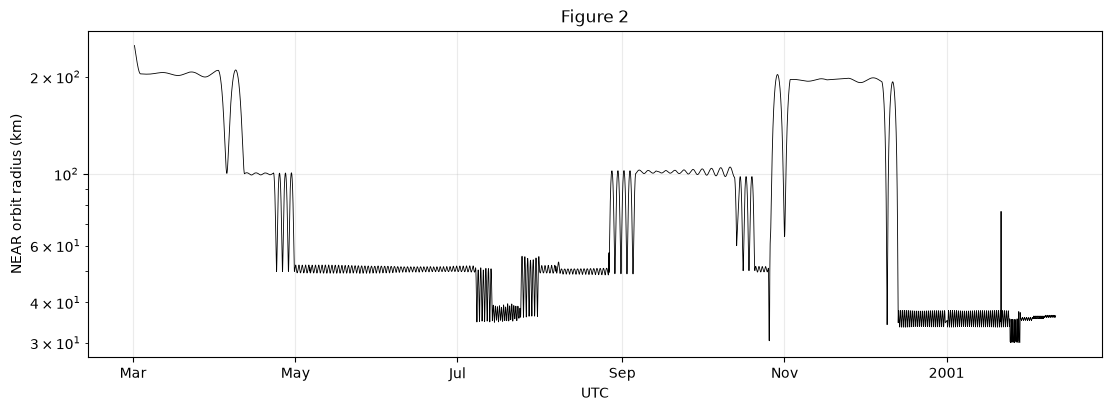

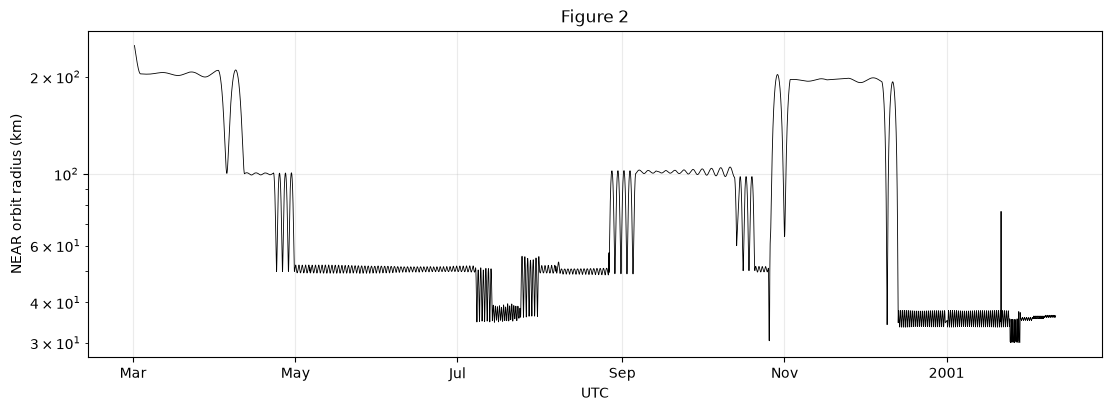

In [5]:
window_times = np.array(metrics["center_unix_s"] * 1000, dtype=np.int64).astype(
    "datetime64[ms]"
).astype(datetime)
figure, axis = plt.subplots(figsize=(11, 4), constrained_layout=True)
axis.plot(window_times, metrics["radius_km"], color="black", linewidth=0.6)
axis.set_yscale("log")
axis.set_ylabel("NEAR orbit radius (km)")
axis.set_xlabel("UTC")
axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(axis.xaxis.get_major_locator()))
axis.grid(alpha=0.25)
axis.set_title("Figure 2")
figure.savefig(output_directory / "figure_2_orbit_radius.png", dpi=180)
figure

## Replicate Figure 3: field strength versus wake angle at 35 km

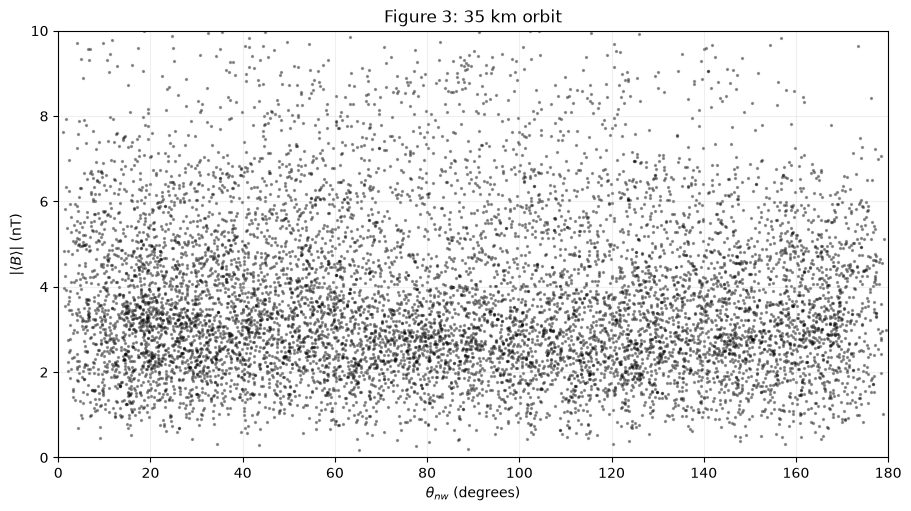

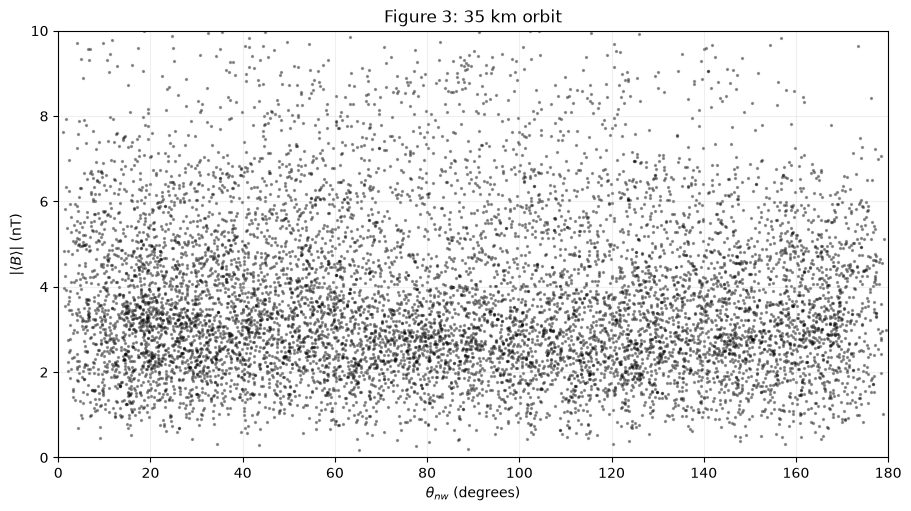

In [6]:
selection = metrics["orbit_km"] == 35
figure, axis = plt.subplots(figsize=(9, 5), constrained_layout=True)
axis.scatter(
    metrics["theta_nw_deg"][selection],
    metrics["mean_b_nt"][selection],
    s=2,
    color="black",
    alpha=0.35,
)
axis.set_xlim(0, 180)
axis.set_ylim(0, 10)
axis.set_xlabel(r"$\theta_{nw}$ (degrees)")
axis.set_ylabel(r"$|\langle B\rangle|$ (nT)")
axis.set_title("Figure 3: 35 km orbit")
axis.grid(alpha=0.2)
figure.savefig(output_directory / "figure_3_scatter.png", dpi=180)
figure

## Occurrence and difference distributions

Histograms are percentages within each angle selection and are smoothed with the paper's three-cell window. The bold line is 0-30 degrees, thin gray lines are the other 30-degree bins, and the dashed line is the aggregate 30-180 degree control.

In [7]:
def occurrence(values, bins, smooth=True):
    finite = values[np.isfinite(values)]
    counts, _ = np.histogram(finite, bins=bins)
    percent = counts / max(counts.sum(), 1) * 100
    if smooth:
        percent = np.convolve(percent, np.ones(3) / 3, mode="same")
    return percent


def angle_selection(radius, low, high):
    return (metrics["orbit_km"] == radius) & (metrics["theta_nw_deg"] >= low) & (
        metrics["theta_nw_deg"] < high
    )


def distributions(metric, radius, bins, transform=lambda values: values, smooth=True):
    result = []
    for low, high in zip(angle_edges[:-1], angle_edges[1:]):
        selection = angle_selection(radius, low, high)
        result.append(occurrence(transform(metrics[metric][selection]), bins, smooth))
    control = (metrics["orbit_km"] == radius) & (metrics["theta_nw_deg"] >= 30)
    return np.array(result), occurrence(transform(metrics[metric][control]), bins, smooth)


def plot_all_orbits(metric, bins, xlabel, filename, transform=lambda values: values):
    centers = (bins[:-1] + bins[1:]) / 2
    figure, axes = plt.subplots(5, 1, figsize=(8, 12), sharex=True, constrained_layout=True)
    for axis, radius in zip(axes[:4], orbit_radii[::-1]):
        angle_histograms, control = distributions(metric, radius, bins, transform)
        for histogram in angle_histograms[1:]:
            axis.plot(centers, histogram, color="0.7", linewidth=0.7)
        axis.plot(centers, angle_histograms[0], color="black", linewidth=1.8, label="0-30 degrees")
        axis.plot(centers, control, color="black", linestyle="--", label="30-180 degrees")
        axis.set_ylabel("occurrence (%)")
        axis.text(0.98, 0.82, f"{radius:.0f} km", transform=axis.transAxes, ha="right")
        axis.grid(alpha=0.15)
    for radius in orbit_radii:
        angle_histograms, control = distributions(metric, radius, bins, transform)
        axes[-1].plot(centers, angle_histograms[0] - control, label=f"{radius:.0f} km")
    axes[-1].axhline(0, color="black", linewidth=0.7)
    axes[-1].set_ylabel("difference (%)")
    axes[-1].set_xlabel(xlabel)
    axes[-1].legend(ncol=4, fontsize=8)
    figure.savefig(output_directory / filename, dpi=180)
    return figure


def plot_one_orbit(metric, bins, xlabel, filename, transform=lambda values: values):
    centers = (bins[:-1] + bins[1:]) / 2
    figure, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
    angle_histograms, control = distributions(metric, 35, bins, transform)
    for histogram in angle_histograms[1:]:
        axes[0].plot(centers, histogram, color="0.7", linewidth=0.7)
    axes[0].plot(centers, angle_histograms[0], color="black", linewidth=1.8)
    axes[0].plot(centers, control, color="black", linestyle="--")
    axes[0].set_ylabel("occurrence (%)")
    axes[0].set_title("35 km orbit")
    for radius in orbit_radii:
        angle_histograms, control = distributions(metric, radius, bins, transform)
        axes[1].plot(centers, angle_histograms[0] - control, label=f"{radius:.0f} km")
    axes[1].axhline(0, color="black", linewidth=0.7)
    axes[1].set_ylabel("difference (%)")
    axes[1].set_xlabel(xlabel)
    axes[1].legend(ncol=4, fontsize=8)
    figure.savefig(output_directory / filename, dpi=180)
    return figure

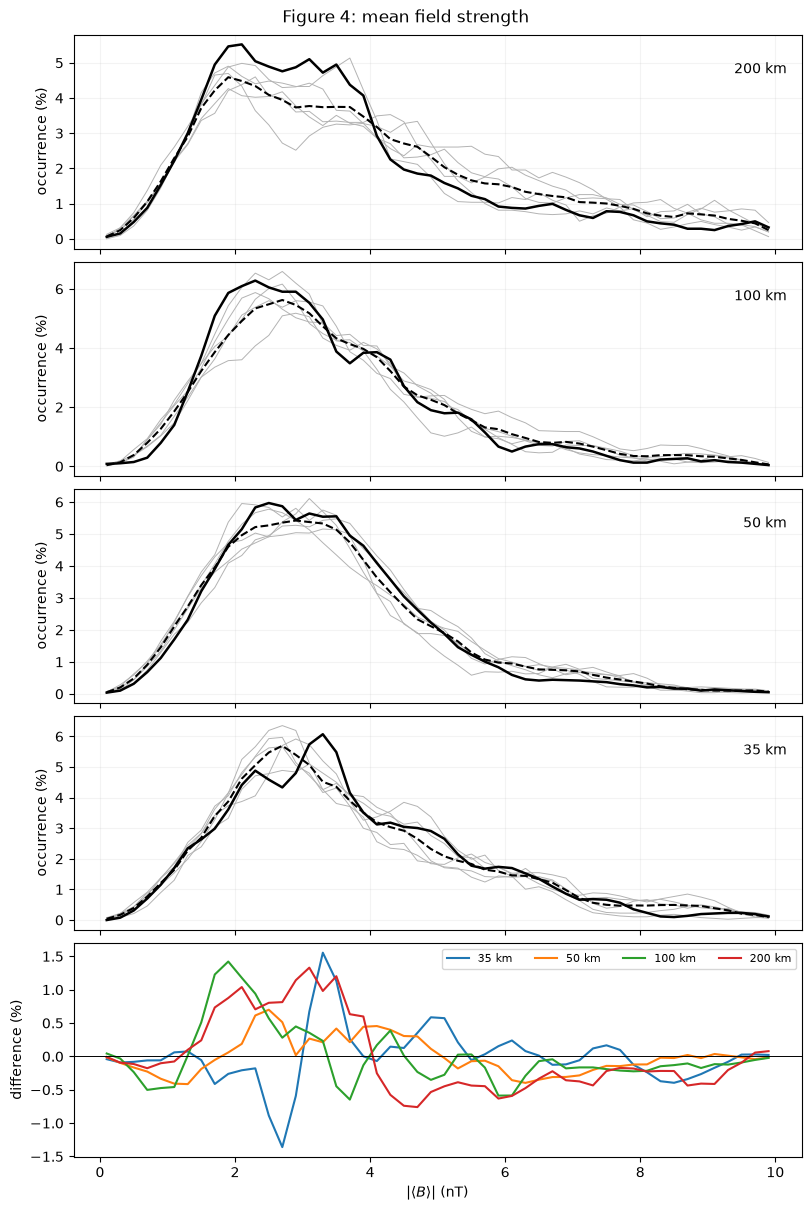

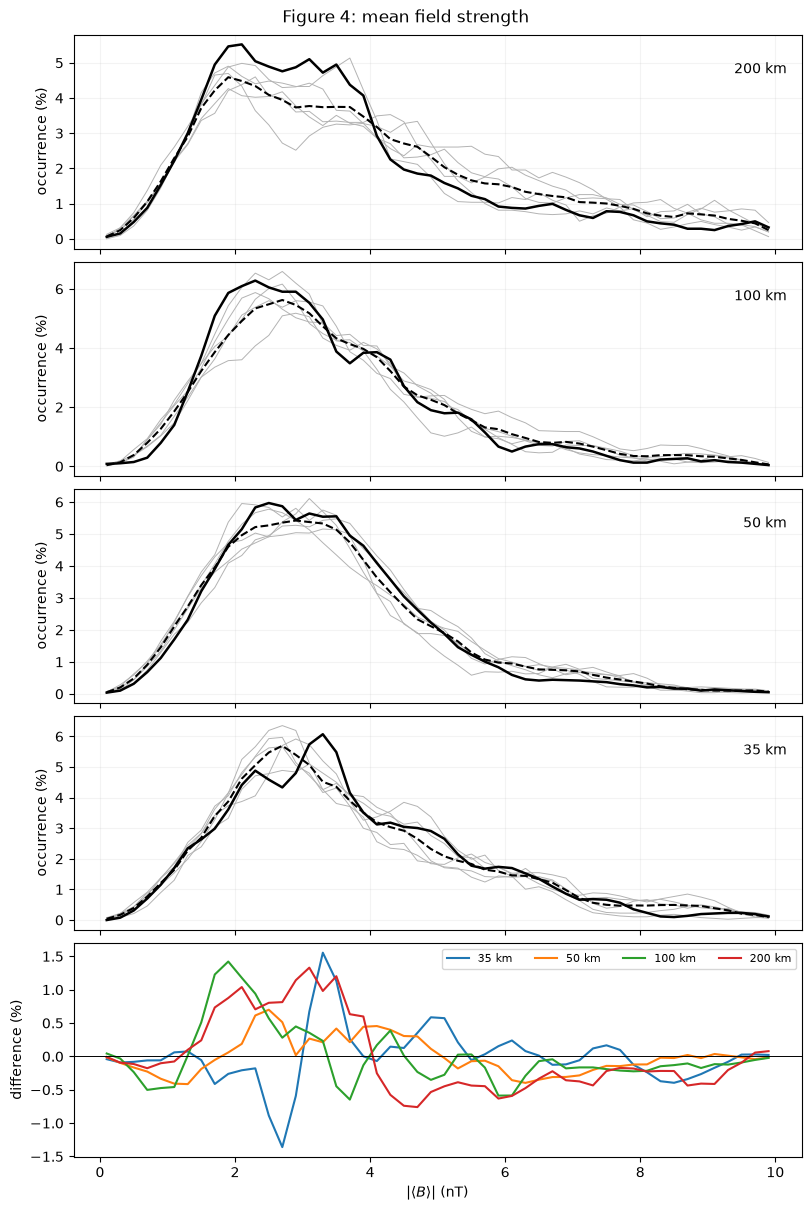

In [8]:
figure_4 = plot_all_orbits(
    "mean_b_nt", np.arange(0, 10.2, 0.2), r"$|\langle B\rangle|$ (nT)", "figure_4_mean_b.png"
)
figure_4.suptitle("Figure 4: mean field strength")
figure_4.savefig(output_directory / "figure_4_mean_b.png", dpi=180)
figure_4

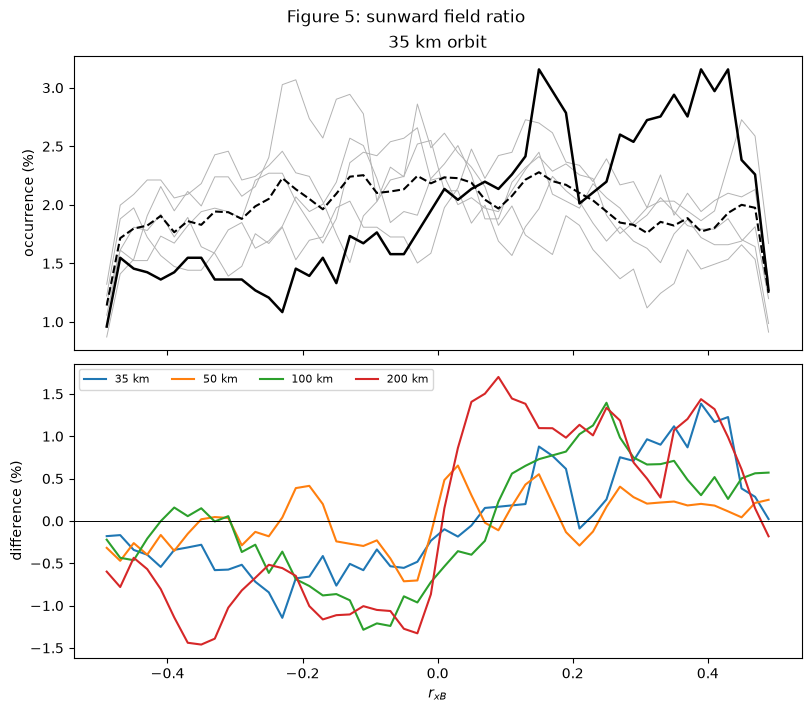

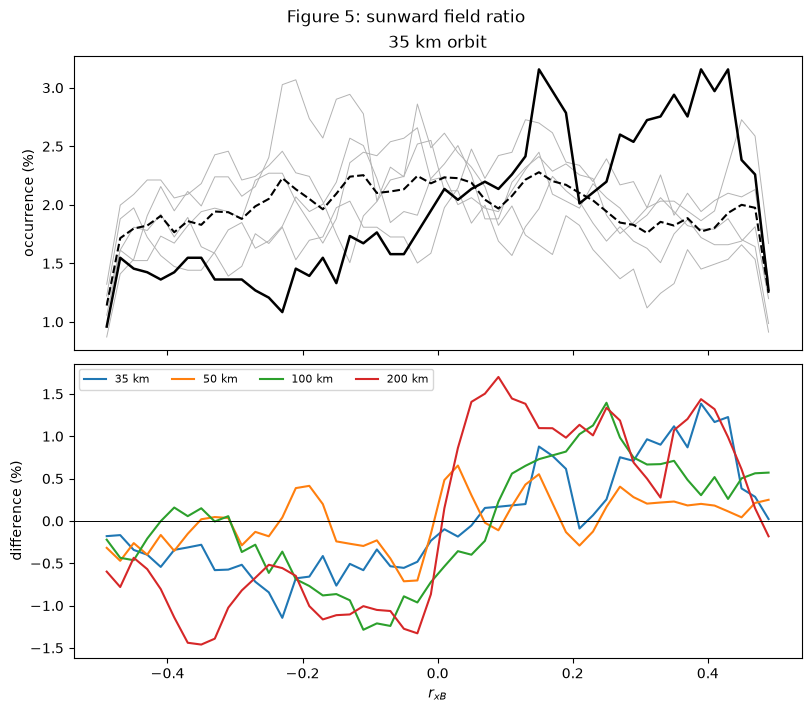

In [9]:
figure_5 = plot_one_orbit(
    "rx_b", np.arange(-0.5, 0.52, 0.02), r"$r_{xB}$", "figure_5_rx_b.png"
)
figure_5.suptitle("Figure 5: sunward field ratio")
figure_5.savefig(output_directory / "figure_5_rx_b.png", dpi=180)
figure_5

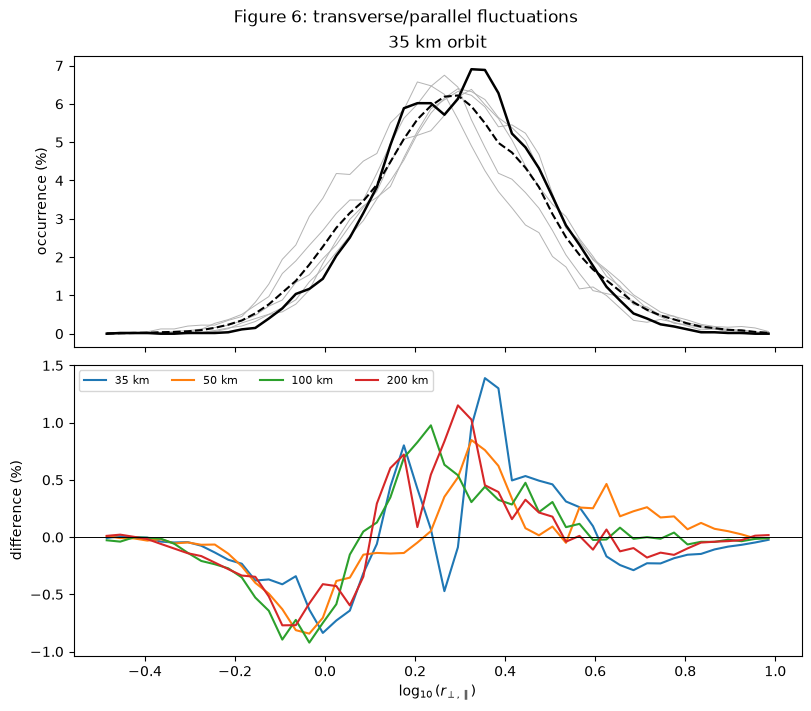

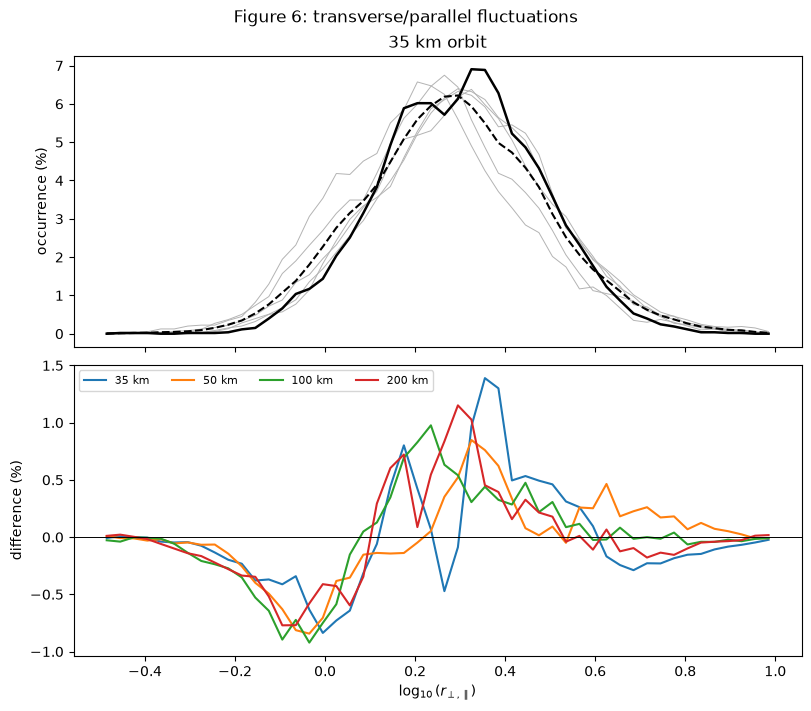

In [10]:
safe_log10 = lambda values: np.log10(np.maximum(np.abs(values), np.finfo(float).tiny))
figure_6 = plot_one_orbit(
    "r_perp_parallel",
    np.linspace(-0.5, 1.0, 51),
    r"$\log_{10}(r_{\perp,\parallel})$",
    "figure_6_fluctuation_ratio.png",
    safe_log10,
)
figure_6.suptitle("Figure 6: transverse/parallel fluctuations")
figure_6.savefig(output_directory / "figure_6_fluctuation_ratio.png", dpi=180)
figure_6

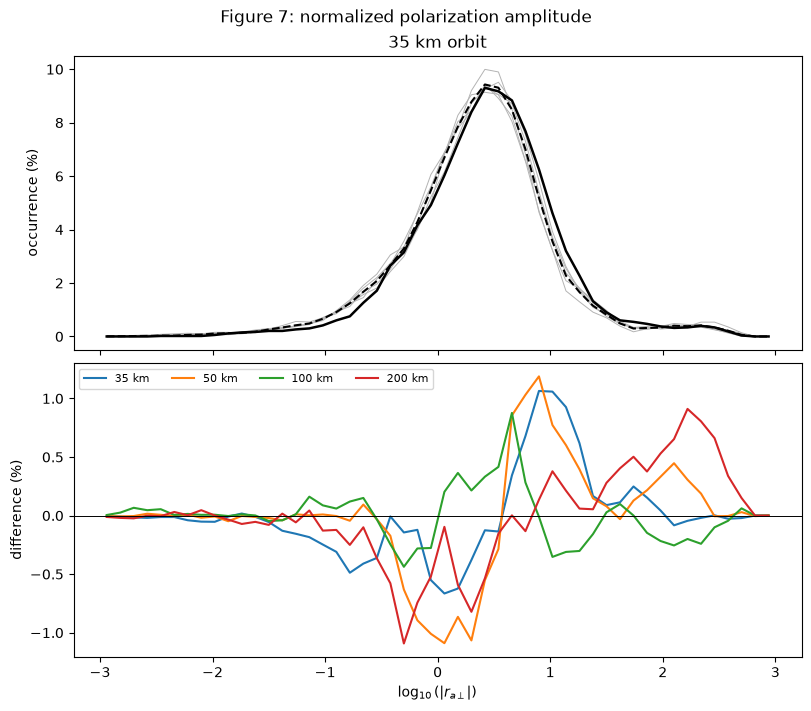

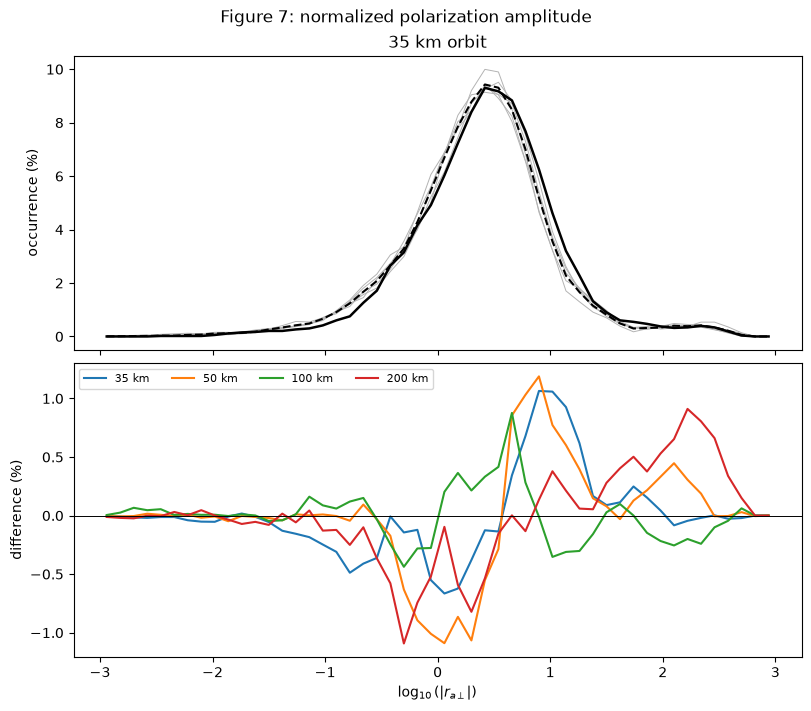

In [11]:
figure_7 = plot_one_orbit(
    "r_a_perp",
    np.linspace(-3, 3, 51),
    r"$\log_{10}(|r_{a\perp}|)$",
    "figure_7_polarization_amplitude.png",
    safe_log10,
)
figure_7.suptitle("Figure 7: normalized polarization amplitude")
figure_7.savefig(output_directory / "figure_7_polarization_amplitude.png", dpi=180)
figure_7

## Audit Figure 8 and replicate Table 1: handedness

Positive `p_a_perp` is right handed and negative is left handed by the paper's convention. There is an internal inconsistency in the published method: equation (3) places every `B_perp` in the plane normal to the single window-mean `b`, so every cross product in equation (5), their sum `a_perp`, and therefore `p_a_perp = a_perp dot b / |a_perp|` must be parallel or antiparallel to `b`. The literal result is exactly +1 or -1 apart from roundoff and cannot produce the broad distribution in published Figure 8. The second panel therefore shows a clearly labeled coherence extension, signed accumulated area divided by accumulated unsigned area. It is useful physically but is not asserted to be the undocumented calculation used by the authors. Table 1 is compared using the literal published definition.

maximum literal |p_a_perp| departure from 1: 4.441e-16
literal published definition
radius  replication 0-30  paper 0-30  replication 30-180  paper 30-180
    35              0.83        0.84                   0.97          0.94
    50              0.83        1.01                   0.92          0.94
   100              0.70        0.84                   0.73          0.68
   200              0.77        0.80                   0.91          0.89
coherence extension
radius  ratio 0-30  ratio 30-180
    35        1.18          1.24
    50        0.94          1.10
   100        1.09          1.14
   200        1.39          1.01


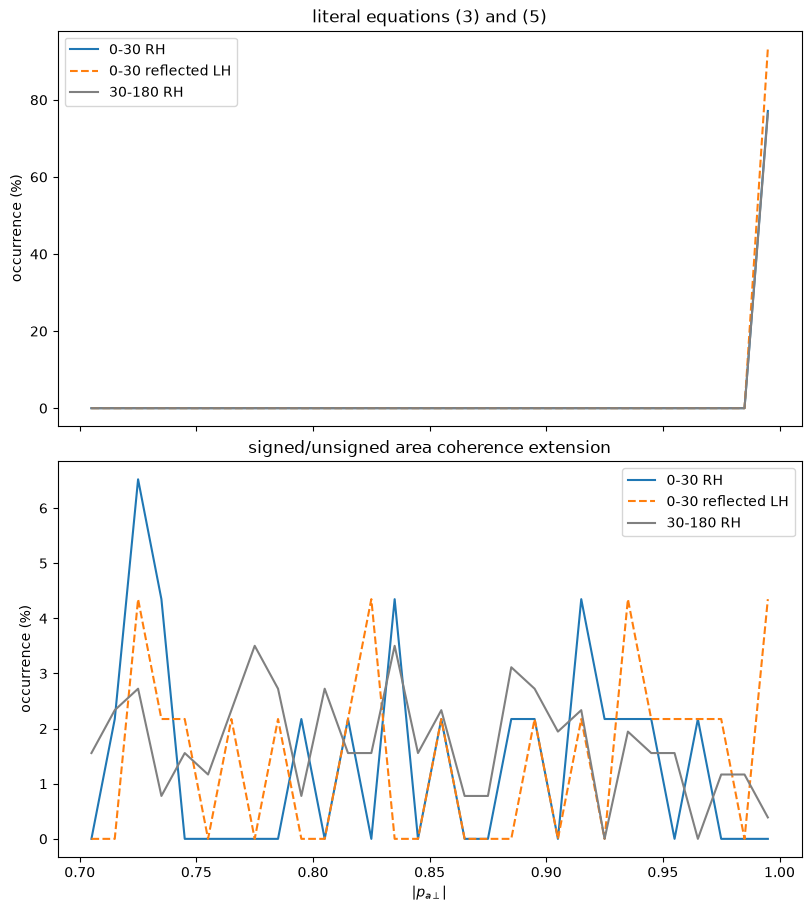

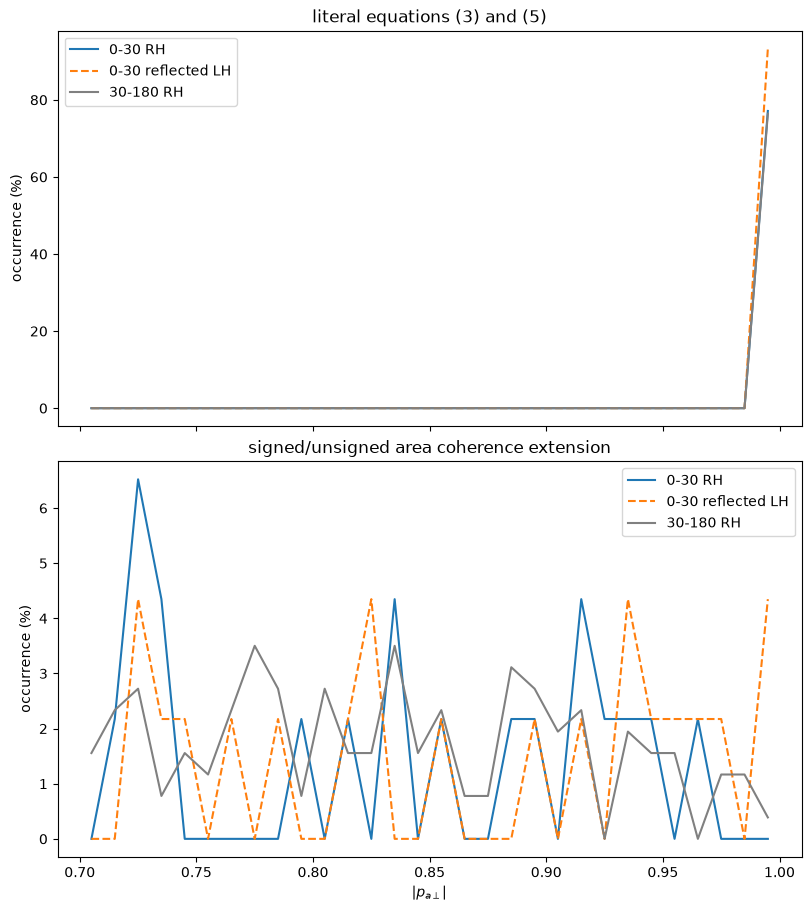

In [12]:
def handedness_ratio(metric, radius, low, high):
    selection = angle_selection(radius, low, high)
    polarization = metrics[metric][selection]
    right = np.count_nonzero(polarization > 0.5)
    left = np.count_nonzero(polarization < -0.5)
    return right / left if left else np.nan, right, left


def normalized_polarization(values, bins, normalization_count):
    counts, _ = np.histogram(values, bins=bins)
    return counts / max(normalization_count, 1) * 100


def plot_polarization(axis, metric, bins, title):
    wake = angle_selection(35, 0, 30)
    control = (metrics["orbit_km"] == 35) & (metrics["theta_nw_deg"] >= 30)
    polarization = metrics[metric]
    positive_wake = polarization[wake & (polarization > 0.5)]
    negative_wake = -polarization[wake & (polarization < -0.5)]
    positive_control = polarization[control & (polarization > 0.5)]
    centers = (bins[:-1] + bins[1:]) / 2
    axis.plot(centers, normalized_polarization(positive_wake, bins, positive_wake.size), label="0-30 RH")
    axis.plot(centers, normalized_polarization(negative_wake, bins, positive_wake.size), linestyle="--", label="0-30 reflected LH")
    axis.plot(centers, normalized_polarization(positive_control, bins, positive_control.size), color="0.5", label="30-180 RH")
    axis.set_ylabel("occurrence (%)")
    axis.set_title(title)
    axis.legend()


bins = np.linspace(0.7, 1.0, 31)
figure, axes = plt.subplots(2, 1, figsize=(8, 9), sharex=True, constrained_layout=True)
plot_polarization(axes[0], "p_a_perp", bins, "literal equations (3) and (5)")
plot_polarization(axes[1], "p_a_perp_coherence", bins, "signed/unsigned area coherence extension")
axes[1].set_xlabel(r"$|p_{a\perp}|$")
maximum_departure = np.max(np.abs(np.abs(metrics["p_a_perp"]) - 1))
print(f"maximum literal |p_a_perp| departure from 1: {maximum_departure:.3e}")
figure.savefig(output_directory / "figure_8_handedness.png", dpi=180)

paper_ratios = {35: (0.84, 0.94), 50: (1.01, 0.94), 100: (0.84, 0.68), 200: (0.80, 0.89)}
print("literal published definition")
print("radius  replication 0-30  paper 0-30  replication 30-180  paper 30-180")
for radius in orbit_radii:
    wake_ratio, _, _ = handedness_ratio("p_a_perp", radius, 0, 30)
    control_ratio, _, _ = handedness_ratio("p_a_perp", radius, 30, 180)
    expected = paper_ratios[int(radius)]
    print(
        f"{radius:6.0f} {wake_ratio:17.2f} {expected[0]:11.2f} "
        f"{control_ratio:22.2f} {expected[1]:13.2f}"
    )
print("coherence extension")
print("radius  ratio 0-30  ratio 30-180")
for radius in orbit_radii:
    wake_ratio, _, _ = handedness_ratio("p_a_perp_coherence", radius, 0, 30)
    control_ratio, _, _ = handedness_ratio("p_a_perp_coherence", radius, 30, 180)
    print(f"{radius:6.0f} {wake_ratio:11.2f} {control_ratio:13.2f}")
figure

## Extension: effect sizes, bootstrap intervals, and false-discovery control

From this point on are my own tests of the paper results. Compares the expected wake region (0-30 degrees) with the 30-180 degree control using mean differences, 95% bootstrap intervals, Mann-Whitney tests, and Benjamini-Hochberg correction across all orbit/metric tests. Treat the windows as approximately independent only as a first pass; further analysis should also use orbit-block resampling.

In [13]:
def bootstrap_difference(wake_values, control_values, draws, generator):
    wake_values = wake_values[np.isfinite(wake_values)]
    control_values = control_values[np.isfinite(control_values)]
    estimate = float(np.mean(wake_values) - np.mean(control_values))
    differences = np.empty(draws)
    for index in range(draws):
        wake_sample = generator.choice(wake_values, wake_values.size, replace=True)
        control_sample = generator.choice(control_values, control_values.size, replace=True)
        differences[index] = np.mean(wake_sample) - np.mean(control_sample)
    lower, upper = np.percentile(differences, [2.5, 97.5])
    return estimate, float(lower), float(upper)


def benjamini_hochberg(pvalues):
    pvalues = np.asarray(pvalues)
    order = np.argsort(pvalues)
    ranked = pvalues[order] * pvalues.size / np.arange(1, pvalues.size + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    adjusted = np.empty_like(ranked)
    adjusted[order] = np.minimum(ranked, 1)
    return adjusted


tests = {
    "mean_b_nt": lambda values: values,
    "rx_b": lambda values: values,
    "log10_r_perp_parallel": safe_log10,
    "log10_abs_r_a_perp": safe_log10,
}
source_metrics = {
    "mean_b_nt": "mean_b_nt",
    "rx_b": "rx_b",
    "log10_r_perp_parallel": "r_perp_parallel",
    "log10_abs_r_a_perp": "r_a_perp",
}
generator = np.random.default_rng(random_seed)
results = []
for radius in orbit_radii:
    wake = angle_selection(radius, 0, 30)
    control = (metrics["orbit_km"] == radius) & (metrics["theta_nw_deg"] >= 30)
    for name, transform in tests.items():
        source = source_metrics[name]
        wake_values = transform(metrics[source][wake])
        control_values = transform(metrics[source][control])
        estimate, lower, upper = bootstrap_difference(
            wake_values, control_values, bootstrap_draws, generator
        )
        pvalue = stats.mannwhitneyu(
            wake_values, control_values, alternative="two-sided"
        ).pvalue
        results.append(
            {
                "radius_km": radius,
                "metric": name,
                "difference": estimate,
                "ci_lower": lower,
                "ci_upper": upper,
                "pvalue": pvalue,
            }
        )
adjusted = benjamini_hochberg([result["pvalue"] for result in results])
for result, adjusted_pvalue in zip(results, adjusted):
    result["adjusted_pvalue"] = adjusted_pvalue

print("radius metric                         difference       95% CI                 p_adj")
for result in results:
    print(
        f"{result['radius_km']:6.0f} {result['metric']:28s} "
        f"{result['difference']:10.4g} "
        f"[{result['ci_lower']:9.4g}, {result['ci_upper']:9.4g}] "
        f"{result['adjusted_pvalue']:9.3g}"
    )

radius metric                         difference       95% CI                 p_adj
    35 mean_b_nt                       -0.4534 [  -0.7015,   -0.2308]     0.739
    35 rx_b                              0.075 [  0.04895,    0.1006]  4.29e-09
    35 log10_r_perp_parallel           0.01909 [ 0.009762,   0.02866]  0.000777
    35 log10_abs_r_a_perp              0.07845 [  0.04719,    0.1096]     2e-06
    50 mean_b_nt                         -0.21 [  -0.3945,   0.01193]     0.638
    50 rx_b                            0.04167 [  0.01829,   0.06483]  0.000128
    50 log10_r_perp_parallel           0.03283 [   0.0244,   0.04146]  1.92e-10
    50 log10_abs_r_a_perp              0.08074 [  0.05433,    0.1102]  2.21e-10
   100 mean_b_nt                       -0.5043 [  -0.7178,   -0.2861]  9.32e-05
   100 rx_b                            0.06778 [  0.04248,    0.0939]  1.78e-07
   100 log10_r_perp_parallel           0.02966 [  0.01952,   0.04004]  6.46e-06
   100 log10_abs_r_a_perp           

## Extension: artifact sensitivity

The PDS documentation warns of calibration and propulsion spikes. The paper emphasizes statistical signatures but does not state an explicit spike filter. This cell reports how many windows would be removed by a conservative Btotal threshold so the replication can be compared both with and without that extra choice.

In [14]:
artifact_threshold_nt = 100
artifact = metrics["maximum_btotal_nt"] > artifact_threshold_nt
print(f"windows above {artifact_threshold_nt} nT: {np.count_nonzero(artifact):,}")
print(f"fraction of retained windows: {np.mean(artifact):.3%}")
for radius in orbit_radii:
    selection = metrics["orbit_km"] == radius
    print(
        f"{radius:3.0f} km: {np.count_nonzero(artifact & selection):4,d} / "
        f"{np.count_nonzero(selection):6,d}"
    )

windows above 100 nT: 106
fraction of retained windows: 0.223%
 35 km:   25 / 10,287
 50 km:   36 / 16,967
100 km:   23 / 10,065
200 km:   22 / 10,263


## Extension: multitaper magnetic spectral matrix

This extension rotates each window into a right-handed field-aligned basis and estimates the complex 3 by 3 magnetic cross-spectral matrix with DPSS tapers. The default interval is one day in the close-orbit phase and is controlled by the variables at the top of the notebook. Set `spectral_scan_start = start` and `spectral_scan_stop = stop` to scan the full orbital record.

In [15]:
def field_aligned_coordinates(vectors):
    mean_vector = np.mean(vectors, axis=0)
    mean_magnitude = np.linalg.norm(mean_vector)
    if mean_magnitude == 0:
        raise ValueError("mean magnetic field is zero")
    parallel_axis = mean_vector / mean_magnitude
    reference_axis = np.array([0.0, 0.0, 1.0])
    if abs(reference_axis @ parallel_axis) > 0.9:
        reference_axis = np.array([0.0, 1.0, 0.0])
    first_axis = np.cross(reference_axis, parallel_axis)
    first_axis /= np.linalg.norm(first_axis)
    second_axis = np.cross(parallel_axis, first_axis)
    basis = np.column_stack((first_axis, second_axis, parallel_axis))
    fluctuations = signal.detrend(vectors, axis=0, type="linear")
    return fluctuations @ basis, basis, mean_vector


def multitaper_spectral_matrix(vectors, cadence):
    field_aligned, basis, mean_vector = field_aligned_coordinates(vectors)
    sample_count = field_aligned.shape[0]
    taper_count = min(spectral_taper_count, sample_count - 1)
    tapers, concentrations = signal.windows.dpss(
        sample_count,
        spectral_time_bandwidth,
        Kmax=taper_count,
        return_ratios=True,
    )
    tapered = tapers[:, :, None] * field_aligned[None, :, :]
    fourier = np.fft.rfft(tapered, axis=1)
    matrix = np.einsum(
        "kfi,kfj,k->fij", fourier, np.conjugate(fourier), concentrations
    )
    matrix /= np.sum(concentrations) / cadence
    if sample_count % 2 == 0:
        matrix[1:-1] *= 2
    else:
        matrix[1:] *= 2
    frequencies = np.fft.rfftfreq(sample_count, cadence)
    return {
        "frequency_hz": frequencies,
        "matrix": matrix,
        "basis": basis,
        "mean_vector_nt": mean_vector,
        "taper_concentrations": concentrations,
    }


def prepare_spectral_windows(times, vectors):
    seconds = times.astype("datetime64[ms]").astype(np.int64) / 1000
    first = parse_time(spectral_scan_start).timestamp()
    last = parse_time(spectral_scan_stop).timestamp()
    keep = (seconds >= first) & (seconds < last)
    seconds = seconds[keep]
    vectors = vectors[keep]
    window_id = np.floor(seconds / spectral_window_seconds).astype(np.int64)
    identifiers, first_indices, counts = np.unique(
        window_id, return_index=True, return_counts=True
    )
    windows = []
    for identifier, first_index, count in zip(identifiers, first_indices, counts):
        if count < spectral_minimum_samples:
            continue
        selection = slice(first_index, first_index + count)
        source_times, unique_indices = np.unique(
            seconds[selection], return_index=True
        )
        source_vectors = vectors[selection][unique_indices]
        steps = np.diff(source_times)
        positive_steps = steps[steps > 0]
        if positive_steps.size == 0:
            continue
        cadence = float(np.median(positive_steps))
        expected_count = int(round(spectral_window_seconds / cadence))
        coverage = source_times.size / max(expected_count, 1)
        if expected_count < spectral_minimum_samples:
            continue
        if coverage < spectral_minimum_coverage:
            continue
        if np.max(positive_steps) > cadence * spectral_maximum_gap_factor:
            continue
        window_start = identifier * spectral_window_seconds
        regular_times = window_start + np.arange(expected_count) * cadence
        regular_vectors = np.column_stack(
            [
                np.interp(regular_times, source_times, source_vectors[:, index])
                for index in range(3)
            ]
        )
        windows.append(
            {
                "center_unix_s": window_start + spectral_window_seconds / 2,
                "cadence_s": cadence,
                "coverage": coverage,
                "vectors_nt": regular_vectors,
            }
        )
    if not windows:
        raise ValueError("no valid spectral windows in the selected interval")
    return windows


spectral_windows = prepare_spectral_windows(times, field[:, :3])
example_spectrum = multitaper_spectral_matrix(spectral_windows[0]["vectors_nt"], spectral_windows[0]["cadence_s"])
print(f"prepared {len(spectral_windows):,} valid multitaper windows")
cadences = np.array([window["cadence_s"] for window in spectral_windows])
print(f"cadence range: {np.min(cadences):.1f}-{np.max(cadences):.1f} s")
print(f"Nyquist range: {0.5 / np.max(cadences):.4f}-{0.5 / np.min(cadences):.4f} Hz")
print("DPSS concentration ratios:", np.round(example_spectrum["taper_concentrations"], 4))

prepared 123 valid multitaper windows
cadence range: 1.0-10.0 s
Nyquist range: 0.0500-0.5000 Hz
DPSS concentration ratios: [1.     0.9998 0.9963 0.9525]


## Extension: frequency-resolved helicity and ellipticity

The transverse 2 by 2 block of the spectral matrix is converted to Stokes-like parameters. Normalized magnetic helicity measures signed circular polarization, ellipticity distinguishes linear from circular polarization, degree of polarization rejects incoherent power, and magnetic compressibility separates transverse from parallel fluctuations. The sign is defined in the right-handed field-aligned basis and is verified by the injection cell below.

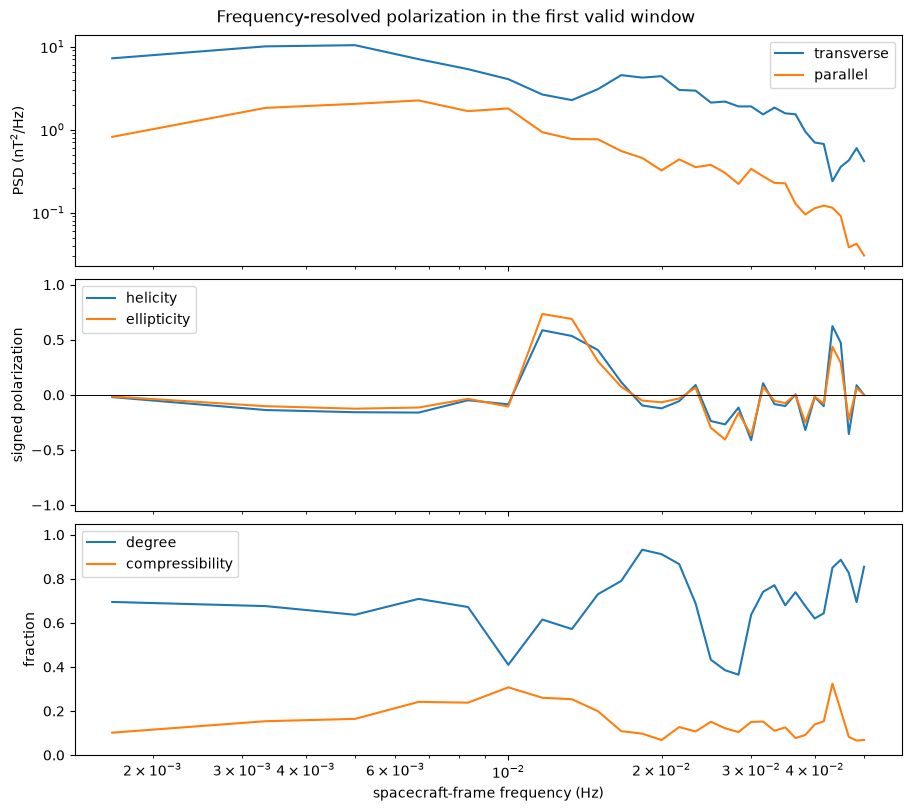

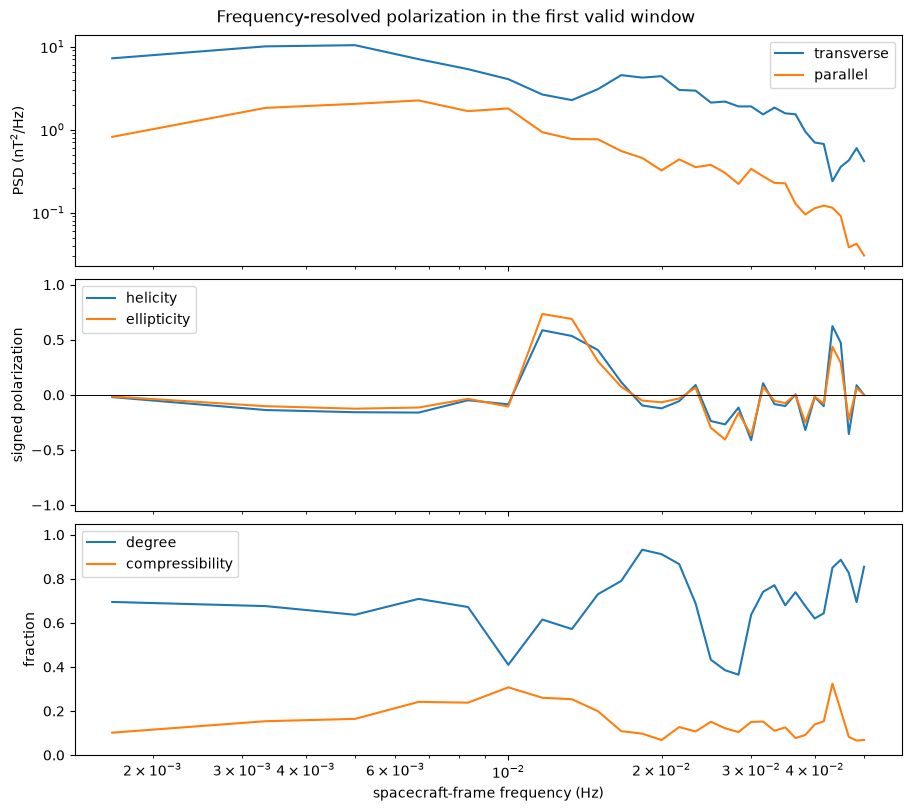

In [16]:
def spectral_polarization(matrix):
    sxx = np.real(matrix[:, 0, 0])
    syy = np.real(matrix[:, 1, 1])
    szz = np.real(matrix[:, 2, 2])
    sxy = matrix[:, 0, 1]
    transverse_power = np.maximum(sxx + syy, np.finfo(float).tiny)
    total_power = np.maximum(transverse_power + szz, np.finfo(float).tiny)
    stokes_q = sxx - syy
    stokes_u = 2 * np.real(sxy)
    stokes_v = 2 * np.imag(sxy)
    polarized_power = np.sqrt(stokes_q**2 + stokes_u**2 + stokes_v**2)
    degree = np.clip(polarized_power / transverse_power, 0, 1)
    helicity = np.clip(stokes_v / transverse_power, -1, 1)
    ellipticity_angle = 0.5 * np.arcsin(
        np.clip(stokes_v / np.maximum(polarized_power, np.finfo(float).tiny), -1, 1)
    )
    ellipticity = np.tan(ellipticity_angle)
    return {
        "transverse_power": transverse_power,
        "parallel_power": szz,
        "total_power": total_power,
        "compressibility": np.clip(szz / total_power, 0, 1),
        "degree_of_polarization": degree,
        "normalized_helicity": helicity,
        "ellipticity": ellipticity,
    }


example_polarization = spectral_polarization(example_spectrum["matrix"])
positive_frequency = example_spectrum["frequency_hz"] > 0
figure, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True, constrained_layout=True)
frequencies = example_spectrum["frequency_hz"][positive_frequency]
axes[0].loglog(frequencies, example_polarization["transverse_power"][positive_frequency], label="transverse")
axes[0].loglog(frequencies, example_polarization["parallel_power"][positive_frequency], label="parallel")
axes[0].set_ylabel(r"PSD (nT$^2$/Hz)")
axes[0].legend()
axes[1].semilogx(frequencies, example_polarization["normalized_helicity"][positive_frequency], label="helicity")
axes[1].semilogx(frequencies, example_polarization["ellipticity"][positive_frequency], label="ellipticity")
axes[1].axhline(0, color="black", linewidth=0.7)
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_ylabel("signed polarization")
axes[1].legend()
axes[2].semilogx(frequencies, example_polarization["degree_of_polarization"][positive_frequency], label="degree")
axes[2].semilogx(frequencies, example_polarization["compressibility"][positive_frequency], label="compressibility")
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("fraction")
axes[2].set_xlabel("spacecraft-frame frequency (Hz)")
axes[2].legend()
figure.suptitle("Frequency-resolved polarization in the first valid window")
figure.savefig(output_directory / "extension_multitaper_polarization.png", dpi=180)
figure

## Extension: SVD wave-normal and planarity analysis

For each frequency, the real and imaginary parts of the magnetic spectral matrix form an overdetermined system. The right singular vector associated with the smallest singular value estimates the wave-normal direction. Magnetic-only measurements leave a 180-degree ambiguity, so the reported angle is folded into 0-90 degrees. The scan ranks bands that combine spectral excess, helicity, degree of polarization, planarity, and low compressibility.

time                       cadence  f_hz    score helicity degree planarity theta_kb
2001-01-24T11:45:00+00:00     1.0 0.0967   0.634    0.929  0.936     0.983     7.32
2001-01-24T11:35:00+00:00     1.0 0.0283   0.604    0.792  0.938     0.989     6.74
2001-01-24T23:45:00+00:00     1.0 0.4417   0.602   -0.925  0.925     0.914    27.81
2001-01-24T21:35:00+00:00    10.0 0.0217   0.581   -0.928  0.940     0.968     5.23
2001-01-24T21:55:00+00:00     1.0 0.2033   0.552    0.804  0.976     0.997    14.84
2001-01-24T02:05:00+00:00    10.0 0.0367   0.533   -0.805  0.946     0.994    25.04
2001-01-24T22:05:00+00:00     1.0 0.1967   0.531    0.770  0.988     0.993    29.27
2001-01-24T23:55:00+00:00     1.0 0.0800   0.509    0.740  0.936     0.963     9.60
2001-01-24T19:45:00+00:00    10.0 0.0150   0.491    0.862  0.946     0.963    16.20
2001-01-24T18:15:00+00:00    10.0 0.0367   0.447    0.628  0.869     0.986     6.13


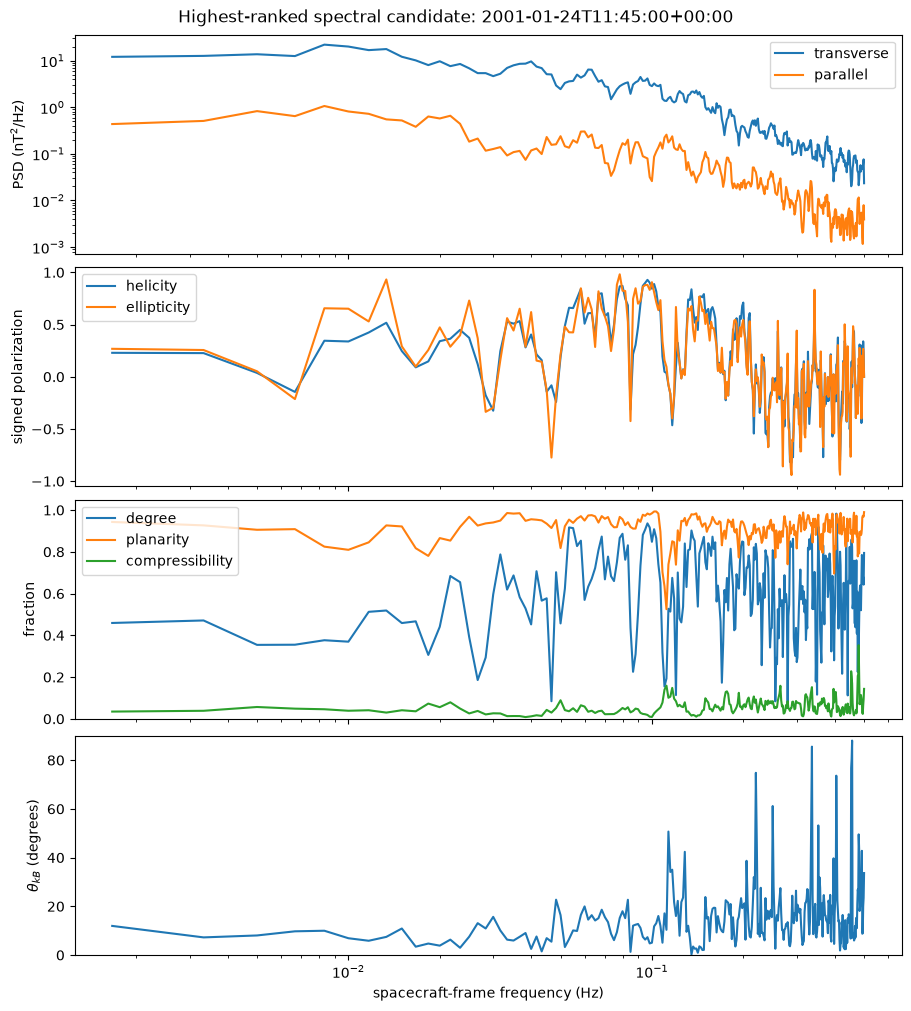

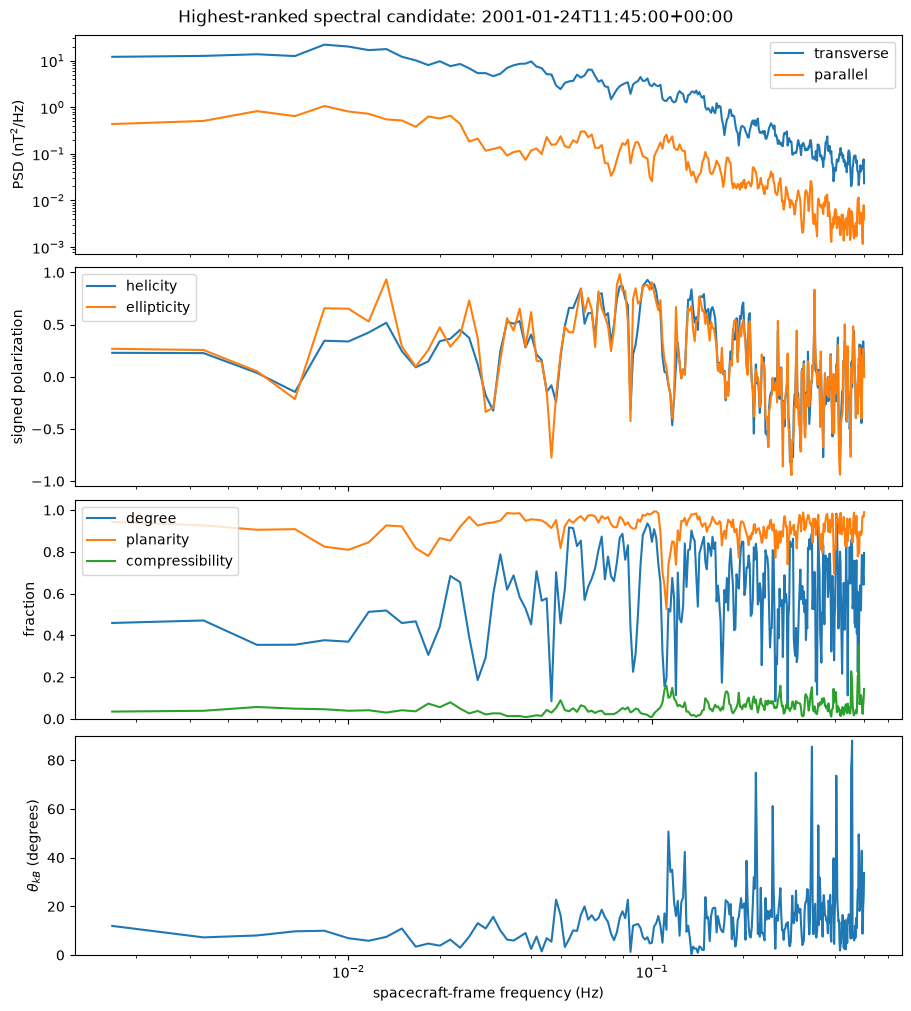

In [17]:
def svd_wave_parameters(matrix):
    wave_normal_angle = np.full(matrix.shape[0], np.nan)
    planarity = np.full(matrix.shape[0], np.nan)
    for index, frequency_matrix in enumerate(matrix):
        system = np.vstack((np.real(frequency_matrix), np.imag(frequency_matrix)))
        _, singular_values, right_vectors = np.linalg.svd(
            system, full_matrices=False
        )
        if singular_values[0] == 0:
            continue
        wave_normal = right_vectors[-1]
        wave_normal_angle[index] = np.degrees(
            np.arccos(np.clip(abs(wave_normal[2]), 0, 1))
        )
        planarity[index] = np.clip(
            1 - singular_values[-1] / singular_values[0], 0, 1
        )
    return {
        "wave_normal_angle_deg": wave_normal_angle,
        "planarity": planarity,
    }


def analyze_spectral_candidate(window):
    spectrum = multitaper_spectral_matrix(
        window["vectors_nt"], window["cadence_s"]
    )
    polarization = spectral_polarization(spectrum["matrix"])
    wave = svd_wave_parameters(spectrum["matrix"])
    frequencies = spectrum["frequency_hz"]
    valid = frequencies >= 2 / spectral_window_seconds
    valid &= frequencies <= frequencies[-1] * 0.9
    log_power = np.log(np.maximum(polarization["transverse_power"], np.finfo(float).tiny))
    background = signal.medfilt(log_power, kernel_size=7)
    peak_ratio = np.exp(log_power - background)
    score = np.log1p(peak_ratio)
    score *= np.abs(polarization["normalized_helicity"])
    score *= polarization["degree_of_polarization"]
    score *= wave["planarity"]
    score *= 1 - polarization["compressibility"]
    candidate_index = np.flatnonzero(valid)[np.argmax(score[valid])]
    return {
        **window,
        **spectrum,
        **polarization,
        **wave,
        "peak_ratio": peak_ratio,
        "score": score,
        "candidate_index": candidate_index,
    }


spectral_results = [analyze_spectral_candidate(window) for window in spectral_windows]
spectral_results.sort(
    key=lambda result: result["score"][result["candidate_index"]], reverse=True
)
print("time                       cadence  f_hz    score helicity degree planarity theta_kb")
for result in spectral_results[:10]:
    index = result["candidate_index"]
    timestamp = datetime.fromtimestamp(result["center_unix_s"], timezone.utc)
    print(
        f"{timestamp.isoformat(timespec='seconds'):25s} "
        f"{result['cadence_s']:7.1f} "
        f"{result['frequency_hz'][index]:6.4f} "
        f"{result['score'][index]:7.3f} "
        f"{result['normalized_helicity'][index]:8.3f} "
        f"{result['degree_of_polarization'][index]:6.3f} "
        f"{result['planarity'][index]:9.3f} "
        f"{result['wave_normal_angle_deg'][index]:8.2f}"
    )

top_result = spectral_results[0]
positive_frequency = top_result["frequency_hz"] > 0
frequencies = top_result["frequency_hz"][positive_frequency]
figure, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
axes[0].loglog(frequencies, top_result["transverse_power"][positive_frequency], label="transverse")
axes[0].loglog(frequencies, top_result["parallel_power"][positive_frequency], label="parallel")
axes[0].set_ylabel(r"PSD (nT$^2$/Hz)")
axes[0].legend()
axes[1].semilogx(frequencies, top_result["normalized_helicity"][positive_frequency], label="helicity")
axes[1].semilogx(frequencies, top_result["ellipticity"][positive_frequency], label="ellipticity")
axes[1].set_ylim(-1.05, 1.05)
axes[1].set_ylabel("signed polarization")
axes[1].legend()
axes[2].semilogx(frequencies, top_result["degree_of_polarization"][positive_frequency], label="degree")
axes[2].semilogx(frequencies, top_result["planarity"][positive_frequency], label="planarity")
axes[2].semilogx(frequencies, top_result["compressibility"][positive_frequency], label="compressibility")
axes[2].set_ylim(0, 1.05)
axes[2].set_ylabel("fraction")
axes[2].legend()
axes[3].semilogx(frequencies, top_result["wave_normal_angle_deg"][positive_frequency])
axes[3].set_ylim(0, 90)
axes[3].set_ylabel(r"$\theta_{kB}$ (degrees)")
axes[3].set_xlabel("spacecraft-frame frequency (Hz)")
top_time = datetime.fromtimestamp(top_result["center_unix_s"], timezone.utc)
figure.suptitle(f"Highest-ranked spectral candidate: {top_time.isoformat(timespec='seconds')}")
figure.savefig(output_directory / "extension_svd_top_candidate.png", dpi=180)
figure

## Extension: synthetic injection and recovery

Circular packets of both signs are injected into phase-randomized real NEAR backgrounds. A recovery requires a transverse-power excess, absolute helicity above 0.6, degree of polarization above 0.7, and planarity above 0.7 at the injected frequency. Detection and correct-sign fractions quantify sensitivity instead of assuming that every physical wave would be visible.

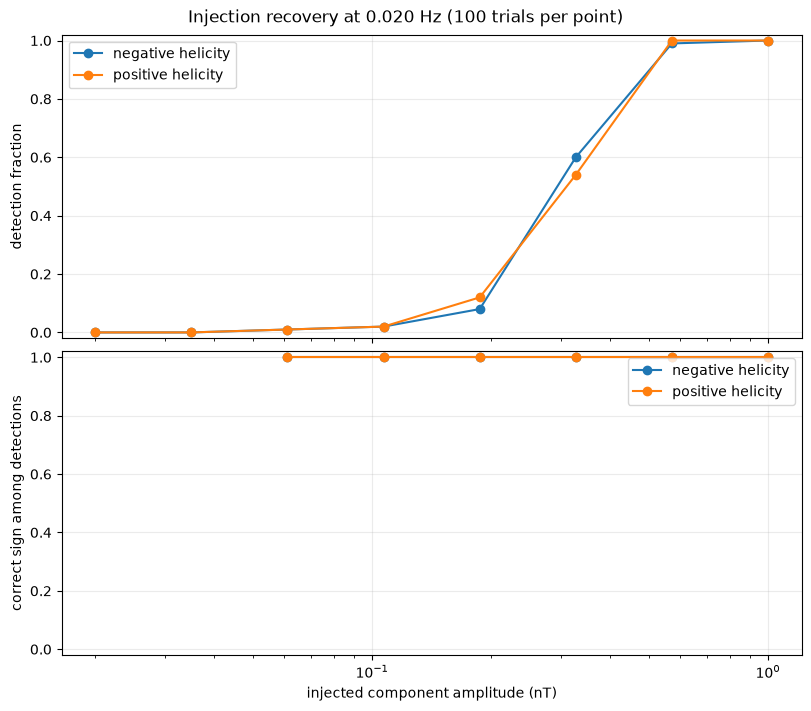

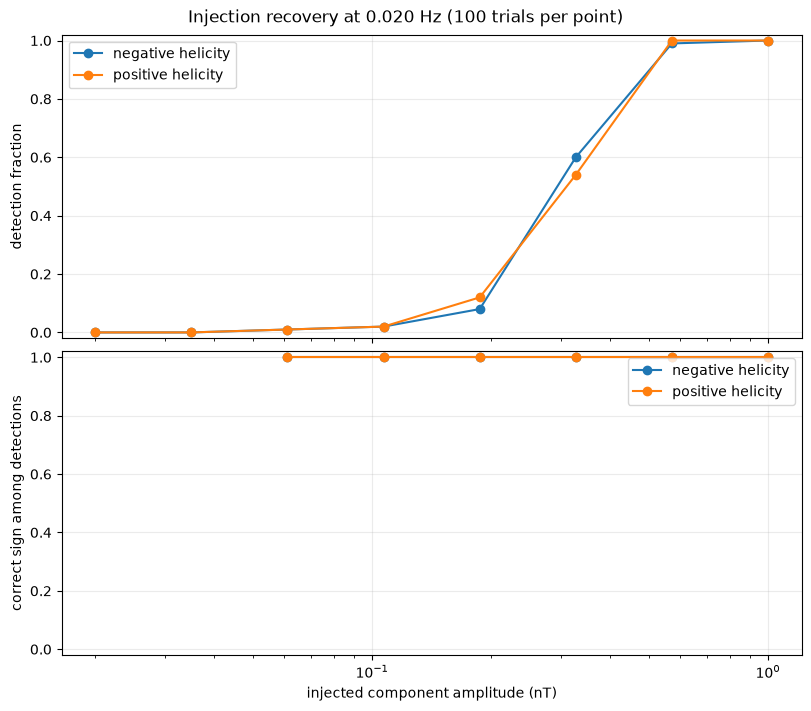

In [18]:
def phase_randomized_background(field_aligned, generator):
    spectrum = np.fft.rfft(field_aligned, axis=0)
    phases = generator.uniform(0, 2 * np.pi, spectrum.shape)
    phases[0] = 0
    if field_aligned.shape[0] % 2 == 0:
        phases[-1] = 0
    randomized = np.abs(spectrum) * np.exp(1j * phases)
    return np.fft.irfft(randomized, n=field_aligned.shape[0], axis=0)


def injection_measurement(background_window, amplitude, handedness, generator):
    field_aligned, basis, mean_vector = field_aligned_coordinates(
        background_window["vectors_nt"]
    )
    surrogate = phase_randomized_background(field_aligned, generator)
    sample_count = surrogate.shape[0]
    time_seconds = np.arange(sample_count) * background_window["cadence_s"]
    phase = generator.uniform(0, 2 * np.pi)
    packet = np.hanning(sample_count)
    wave = np.zeros_like(surrogate)
    wave[:, 0] = amplitude * packet * np.cos(2 * np.pi * injection_frequency_hz * time_seconds + phase)
    wave[:, 1] = handedness * amplitude * packet * np.sin(2 * np.pi * injection_frequency_hz * time_seconds + phase)
    synthetic_vectors = mean_vector + (surrogate + wave) @ basis.T
    synthetic_window = {
        **background_window,
        "vectors_nt": synthetic_vectors,
    }
    result = analyze_spectral_candidate(synthetic_window)
    index = int(np.argmin(np.abs(result["frequency_hz"] - injection_frequency_hz)))
    valid_power = result["transverse_power"][result["frequency_hz"] > 0]
    power_ratio = result["transverse_power"][index] / np.median(valid_power)
    detected = (
        power_ratio >= 3
        and abs(result["normalized_helicity"][index]) >= 0.6
        and result["degree_of_polarization"][index] >= 0.7
        and result["planarity"][index] >= 0.7
    )
    correct_sign = np.sign(result["normalized_helicity"][index]) == handedness
    return detected, bool(correct_sign)


background_window = min(
    spectral_windows,
    key=lambda window: np.std(np.linalg.norm(window["vectors_nt"], axis=1)),
)
generator = np.random.default_rng(random_seed)
injection_results = []
for handedness in (-1, 1):
    for amplitude in injection_amplitudes_nt:
        detections = 0
        correct_signs = 0
        for _ in range(injection_trials):
            detected, correct_sign = injection_measurement(
                background_window, amplitude, handedness, generator
            )
            detections += detected
            correct_signs += detected and correct_sign
        injection_results.append(
            {
                "handedness": handedness,
                "amplitude_nt": amplitude,
                "detection_fraction": detections / injection_trials,
                "correct_sign_fraction": correct_signs / detections if detections else np.nan,
            }
        )

figure, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, constrained_layout=True)
for handedness, label in [(-1, "negative helicity"), (1, "positive helicity")]:
    selected = [result for result in injection_results if result["handedness"] == handedness]
    amplitudes = [result["amplitude_nt"] for result in selected]
    axes[0].semilogx(amplitudes, [result["detection_fraction"] for result in selected], marker="o", label=label)
    axes[1].semilogx(amplitudes, [result["correct_sign_fraction"] for result in selected], marker="o", label=label)
axes[0].set_ylabel("detection fraction")
axes[1].set_ylabel("correct sign among detections")
axes[1].set_xlabel("injected component amplitude (nT)")
for axis in axes:
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)
    axis.legend()
figure.suptitle(f"Injection recovery at {injection_frequency_hz:.3f} Hz ({injection_trials} trials per point)")
figure.savefig(output_directory / "extension_injection_recovery.png", dpi=180)
figure

### Extension method references

- Thomson (1982), *Spectrum estimation and harmonic analysis*, doi:10.1109/PROC.1982.12433
- Santolik et al. (2003), *Singular value decomposition methods for wave propagation analysis*, doi:10.1029/2000RS002523
- Zhao et al. (2018), *Statistical study of low-frequency electromagnetic cyclotron waves in the solar wind at 1 AU*, doi:10.1002/2017JA024979
- Salinas et al. (2025), *An open-source Python version of power spectral density periodicity detection and background estimation using the adaptive multitaper method*, doi:10.1029/2025JA034006